Univerzitet u Sarajevu
<br> Elektrotehnički fakultet
#### **Predmet: Multimedijalni Sistemi**

# Laboratorijska vježba 03:  Huffmanov algoritam kodiranja

---

Za izradu laboratorijske vježbe treba koristiti odgovarajuću Jupyter Notebook datoteku. Urađenu vježbu je potrebno konvertirati u PDF format, a zatim je PDF datoteku potrebno predati do postavljenog roka koristeći platformu Zamger.

Ime i prezime studenta, broj indeksa:

Ismar Muslić, 2366/19304

Datum izrade izvještaja:

30.03.2026.

---

## Zadatak 1.

Potrebno je realizirati **Huffmanov algoritam** kodiranja implementacijom funkcije <code>huffman</code> koja kao parametar prima neku tekstualnu poruku, a kao rezultat vraća listu simbola i listu svih kodova dodijeljenih pojedinačnim simbolima. Možete koristiti funkcije <code>kodiraj</code> i <code>entropija</code> koje su implementirane u prethodnoj laboratorijskoj vježbi, kao i dijelove koda koji se mogu iskoristiti za ovaj algoritam (npr. izračunavanje vjerovatnoće pojavljivanja simbola u poruci).

Huffmanov algoritam se temelji na izgradnji stabla od "dna prema vrhu", za razliku od algoritma Shannon-Fano koji izgrađuje stablo od "vrha prema dnu". Koraci huffmanovog algoritma su:

1. Za zadanu listu simbola, izračunati vjerovatnoće pojavljivanja u poruci.

2. Sortirati simbole prema frekvenciji od najveće do najmanje frekvencije.

3. Iz liste uzeti dva elementa s najmanjom vjerovatnoćom pojavljivanja, jednom elementu dodati vrijednost 0, a drugom dodati vrijednost 1. Voditi računa da se dodavanje simbola vrši na suprotan način u odnosu na Shannon-Fano algoritam kodiranja.

4. Prethodno odabrane elemente dodati u zajedničko podstablo. Podstablo se tretira kao jedan element, a njegova vjerovatnoća pojavljivanja jednaka je sumi vjerovatnoća pojavljivanja simbola koji se nalaze u podstablu.

5. Ponovo sortirati listu simbola prema vjerovatnoći pojavljivanja.

5. Ponavljati korake 3, 4 i 5 dok u listi ne preostane samo jedan element.

Detaljne informacije o samom algoritmu moguće je pronaći u Poglavlju 2 materijala za rad na predmetu, na str. 25 - 29.

Dobivena rješenja za kodne riječi nisu jedinstvena, tj. dobivena rješenja za kodne riječi ovise o specifičnim implementacijskim detaljima. Bitno je da implementacija bude realizirana u skladu sa gore opisanim koracima, tj. u skladu sa algoritmom opisanim na predavanjima.

**Rješenje:**

In [1]:
import math
from collections import Counter

In [2]:
def entropija(poruka):

    simboli = []     # jedinstveni simboli iz poruke
    for i in range(len(poruka)):
        if poruka[i] not in simboli:
            simboli.append(poruka[i])  # dodavanje simbola u listu pri prvom pojavljivanju

    frekvencija = []  # frekvencije pojavljivanja simbola
    for simbol in simboli:
        brojac = poruka.count(simbol)
        frekvencija.append(brojac)

    p = []     # vjerovatnoce pojavljivanja simbola
    for broj in frekvencija:
        p.append(broj / len(poruka))

    vr_entr = 0  # entropija

    # formula Shannonove entropije
    for vjerojatnost in p:
        vr_entr += (vjerojatnost * math.log(1/vjerojatnost, 2))


    return vr_entr

In [36]:
from collections import Counter

class Node:
    def __init__(self, symbol=None, prob=0):
        self.symbol = symbol
        self.prob = prob
        self.left = None
        self.right = None

def huffman(poruka):
    # izracunaj frekvencije
    frekvencije = Counter(poruka)
    ukupno = sum(frekvencije.values())

    # izracunaj vjerovatnoce pojavljivanja
    nodes = []
    for znak, freq in frekvencije.items():
        nodes.append(Node(znak, freq / ukupno))
    
    while len(nodes) > 1:
        # sortiranje po vjerovatnoci pojavljivanja
        nodes = sorted(nodes, key=lambda x: x.prob)
        
        lijevi = nodes[0]
        desni = nodes[1]
        
        # novi cvor
        novi = Node(prob=lijevi.prob + desni.prob)
        novi.left = lijevi
        novi.right = desni
        
        # update-aj stablo
        nodes = nodes[2:]
        nodes.append(novi)
    
    
    kodovi = {}
    
    def generisi(node, kod=""):
        if node is None:
            return
        
        # list (simbol)
        if node.symbol is not None:
            kodovi[node.symbol] = kod
            return
        
        generisi(node.left, kod + "0")
        generisi(node.right, kod + "1")
    
    korijen = nodes[0]
    generisi(korijen)
    
    # za jedan simbol, postavi kod na "0"
    if len(kodovi) == 1:
        kodovi[list(kodovi.keys())[0]] = "0"
    
    # rezultat kao liste
    simboli = list(kodovi.keys())
    kod_lista = list(kodovi.values())
    
    return simboli, kod_lista

In [6]:
def kodiraj(poruka, simboli, kodovi):
    kodirana = ""

    for i in range(len(poruka)):
        j = simboli.index(poruka[i]) # trenutni znak u listi simbola
        kodirana += kodovi[j]        # odgovarajuci kod

    return kodirana

Nakon implementacije funkcije, potrebno je biti moguće izvršiti programski kod ispod tako da daje prikazani ispis. Osim toga, potrebno je pored poruke "BBBAAAAAAAABBCDAAA" dodati još četiri primjera poruka kako bi se implementacija testirala. Dodatna četiri primjera poruka trebaju obavezno biti iz sljedećeg skupa {"A", "DDDDDDDDDDDDDDDDDD", "ABBBBCDECCCCAAAAAAAAAAAAAA", "AAAAAAAAAABBBBBBCCCD"}.

In [37]:
import math
poruka = "BBBAAAAAAAABBCDAAA"

print("Izvorna poruka je:")
print(poruka)

(simboli, kodovi) = huffman(poruka)

print("\nPoruka se sastoji od sljedećih simbola:")
print(", ".join(map(str, simboli))) 

print("\nSkup dobivenih kodnih riječi je:")
print(", ".join(map(str, kodovi))) 

kodirana = kodiraj(poruka, simboli, kodovi)

for i in range(len(simboli)):
  print("\nKod simbola " + simboli[i] + " je " + kodovi [i])

print("\nKodirana poruka je:")
print(kodirana) 
print("\nEntropija poruke je:")
print(round(entropija(poruka),3))
print("\nProsječna dužina kodne riječi u poruci je:")
print(round(len(kodirana)/len(poruka),3))

Izvorna poruka je:
BBBAAAAAAAABBCDAAA

Poruka se sastoji od sljedećih simbola:
C, D, B, A

Skup dobivenih kodnih riječi je:
000, 001, 01, 1

Kod simbola C je 000

Kod simbola D je 001

Kod simbola B je 01

Kod simbola A je 1

Kodirana poruka je:
010101111111110101000001111

Entropija poruke je:
1.411

Prosječna dužina kodne riječi u poruci je:
1.5


In [38]:
import math
poruka = "A"

print("Izvorna poruka je:")
print(poruka)

(simboli, kodovi) = huffman(poruka)

print("\nPoruka se sastoji od sljedećih simbola:")
print(", ".join(map(str, simboli))) 

print("\nSkup dobivenih kodnih riječi je:")
print(", ".join(map(str, kodovi))) 

kodirana = kodiraj(poruka, simboli, kodovi)

for i in range(len(simboli)):
  print("\nKod simbola " + simboli[i] + " je " + kodovi [i])

print("\nKodirana poruka je:")
print(kodirana) 
print("\nEntropija poruke je:")
print(round(entropija(poruka),3))
print("\nProsječna dužina kodne riječi u poruci je:")
print(round(len(kodirana)/len(poruka),3))

Izvorna poruka je:
A

Poruka se sastoji od sljedećih simbola:
A

Skup dobivenih kodnih riječi je:
0

Kod simbola A je 0

Kodirana poruka je:
0

Entropija poruke je:
0.0

Prosječna dužina kodne riječi u poruci je:
1.0


In [39]:
import math
poruka = "DDDDDDDDDDDDDDDDDD"

print("Izvorna poruka je:")
print(poruka)

(simboli, kodovi) = huffman(poruka)

print("\nPoruka se sastoji od sljedećih simbola:")
print(", ".join(map(str, simboli))) 

print("\nSkup dobivenih kodnih riječi je:")
print(", ".join(map(str, kodovi))) 

kodirana = kodiraj(poruka, simboli, kodovi)

for i in range(len(simboli)):
  print("\nKod simbola " + simboli[i] + " je " + kodovi [i])

print("\nKodirana poruka je:")
print(kodirana) 
print("\nEntropija poruke je:")
print(round(entropija(poruka),3))
print("\nProsječna dužina kodne riječi u poruci je:")
print(round(len(kodirana)/len(poruka),3))

Izvorna poruka je:
DDDDDDDDDDDDDDDDDD

Poruka se sastoji od sljedećih simbola:
D

Skup dobivenih kodnih riječi je:
0

Kod simbola D je 0

Kodirana poruka je:
000000000000000000

Entropija poruke je:
0.0

Prosječna dužina kodne riječi u poruci je:
1.0


In [40]:
import math
poruka = "ABBBBCDECCCCAAAAAAAAAAAAAA"

print("Izvorna poruka je:")
print(poruka)

(simboli, kodovi) = huffman(poruka)

print("\nPoruka se sastoji od sljedećih simbola:")
print(", ".join(map(str, simboli))) 

print("\nSkup dobivenih kodnih riječi je:")
print(", ".join(map(str, kodovi))) 

kodirana = kodiraj(poruka, simboli, kodovi)

for i in range(len(simboli)):
  print("\nKod simbola " + simboli[i] + " je " + kodovi [i])

print("\nKodirana poruka je:")
print(kodirana) 
print("\nEntropija poruke je:")
print(round(entropija(poruka),3))
print("\nProsječna dužina kodne riječi u poruci je:")
print(round(len(kodirana)/len(poruka),3))

Izvorna poruka je:
ABBBBCDECCCCAAAAAAAAAAAAAA

Poruka se sastoji od sljedećih simbola:
C, D, E, B, A

Skup dobivenih kodnih riječi je:
00, 0100, 0101, 011, 1

Kod simbola C je 00

Kod simbola D je 0100

Kod simbola E je 0101

Kod simbola B je 011

Kod simbola A je 1

Kodirana poruka je:
101101101101100010001010000000011111111111111

Entropija poruke je:
1.692

Prosječna dužina kodne riječi u poruci je:
1.731


In [41]:
import math
poruka = "AAAAAAAAAABBBBBBCCCD"

print("Izvorna poruka je:")
print(poruka)

(simboli, kodovi) = huffman(poruka)

print("\nPoruka se sastoji od sljedećih simbola:")
print(", ".join(map(str, simboli))) 

print("\nSkup dobivenih kodnih riječi je:")
print(", ".join(map(str, kodovi))) 

kodirana = kodiraj(poruka, simboli, kodovi)

for i in range(len(simboli)):
  print("\nKod simbola " + simboli[i] + " je " + kodovi [i])

print("\nKodirana poruka je:")
print(kodirana) 
print("\nEntropija poruke je:")
print(round(entropija(poruka),3))
print("\nProsječna dužina kodne riječi u poruci je:")
print(round(len(kodirana)/len(poruka),3))

Izvorna poruka je:
AAAAAAAAAABBBBBBCCCD

Poruka se sastoji od sljedećih simbola:
A, D, C, B

Skup dobivenih kodnih riječi je:
0, 100, 101, 11

Kod simbola A je 0

Kod simbola D je 100

Kod simbola C je 101

Kod simbola B je 11

Kodirana poruka je:
0000000000111111111111101101101100

Entropija poruke je:
1.648

Prosječna dužina kodne riječi u poruci je:
1.7


# Dodatni zadatak

![WhatsApp Image 2026-03-30 at 10.37.23.jpeg](<attachment:WhatsApp Image 2026-03-30 at 10.37.23.jpeg>)
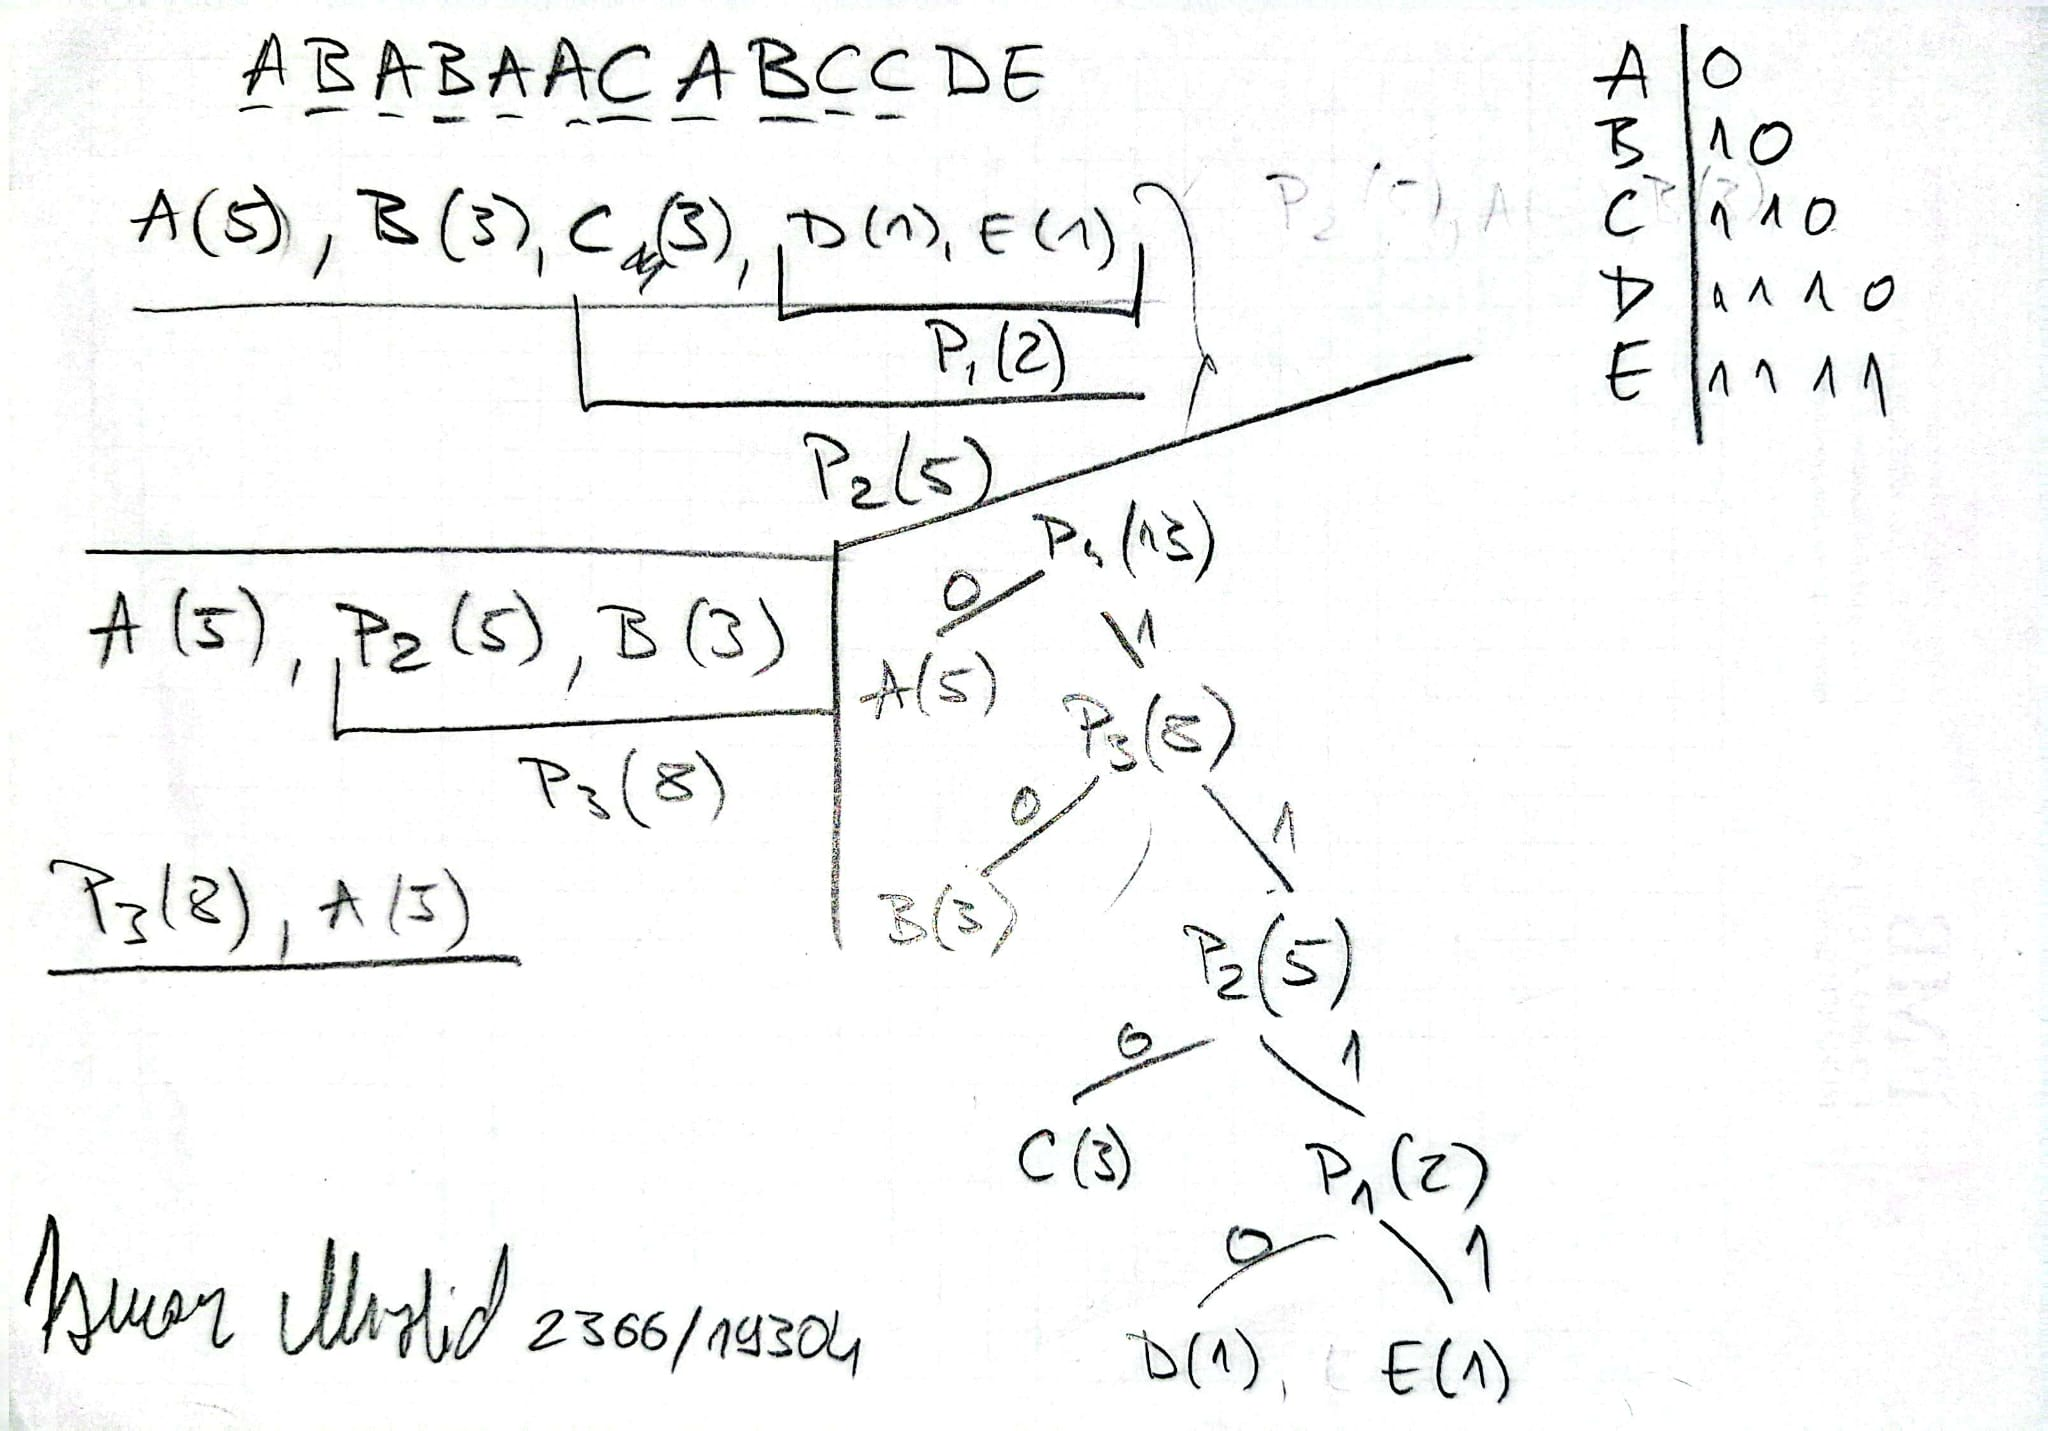